In [1]:
from data.video_dataset import create_datasets
from data.video_dataloader import load_dataloader
from models.action_model import ActionRecognitionModelWithoutSelector,ActionRecognitionModelWithMotionSelector

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import json

c:\Users\javie\Documents\William V\paper\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
root=Path.cwd()
experiments_dir = root/"experiment"

experiment_dir=experiments_dir/"video_swin_prueba_1"

`extract_data_from_dir`

```python
data_dict={
    '0':{
        'train_loss':[...],
        'train_acc':[...],
        'eval_loss':[...],
        'eval_acc':[...],
        'lr':[...]
    },
    '1':{...},
    '2':{...},
    '3':{...},
    '4':{...}
}
```

In [3]:
def extract_data_from_dir(experiment_dir:Path):
    data_dict={}
    for experiment in experiment_dir.iterdir():
        metric_path=experiment/"metrics.json"
        with metric_path.open('r',encoding='utf-8') as f:
            data_dict[experiment.name]=json.load(f)

    return data_dict

In [4]:
results=extract_data_from_dir(experiment_dir)

In [5]:
def plot_results(results:dict):
    metrics=['train_loss','train_acc','eval_loss','eval_acc','lr']
    fig,axes=plt.subplots(3,2,figsize=(12,8))
    axes=axes.flatten()

    for i, metric in enumerate(metrics):
        for name, data in results.items():
            axes[i].plot(data[metric],label=name)

        axes[i].set_title(metric.replace("_"," ").title())
        axes[i].set_xlabel("Epoch")
        axes[i].grid(True)

    axes[0].legend()

    plt.tight_layout()
    plt.show()

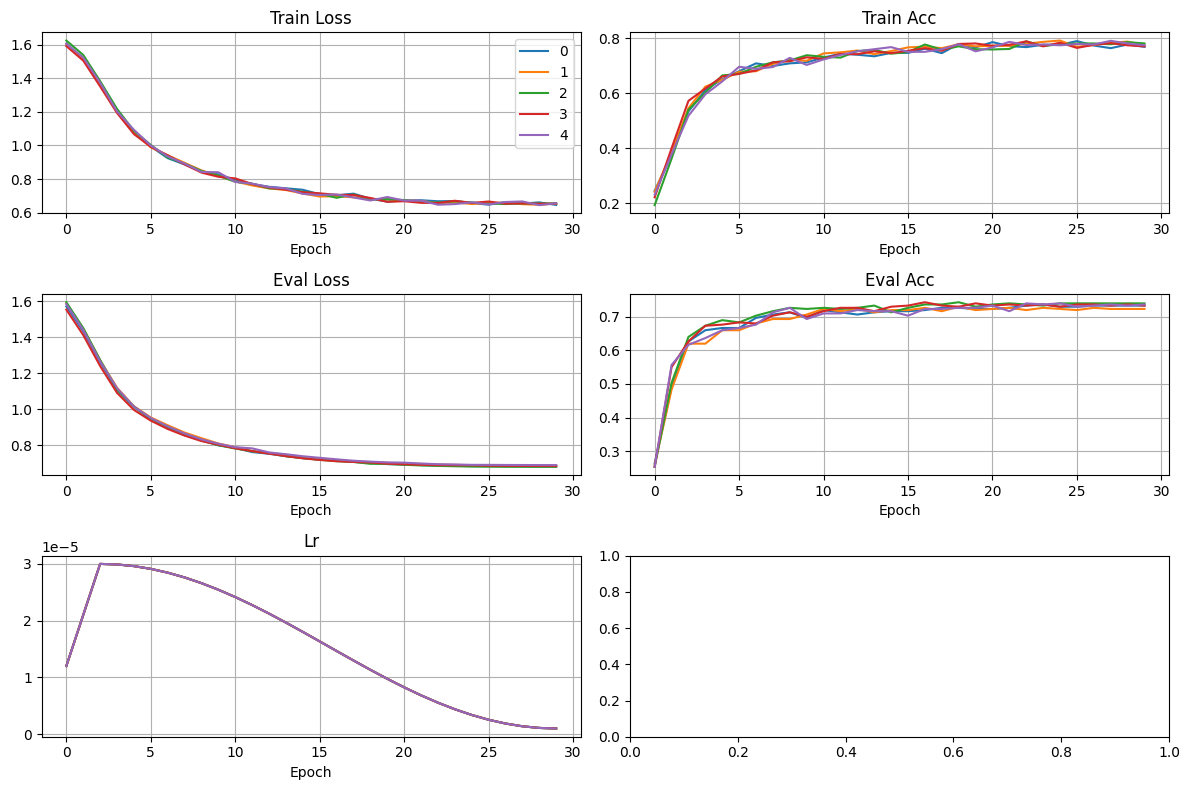

In [6]:
plot_results(results)

In [19]:
from config.load_config import load_config
from data.transform import VideoTrainTransform,VideoValTransform
from utils.helper_functions import set_seed
import torch
import torch.nn as nn
import torchmetrics
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
from tqdm import tqdm

In [27]:
def plot_confussion_matrix(experiment_dir:Path):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


    for experiment in experiment_dir.iterdir():
        cfg=load_config(experiment/"config.yaml")


        data_cfg=cfg.data
        model_cfg=cfg.model
        train_cfg=cfg.train

        seed=int(experiment.name)

        root_path=root/cfg.data.dataset.root

        train_path=root_path/"train"
        val_path=root_path/"val"



        set_seed(seed=seed)

        train_dataset,val_dataset=create_datasets(train_path=train_path,
                                                val_path=val_path,
                                                num_frames=data_cfg.dataset.selector.selected_frames,
                                                strategy=data_cfg.dataset.selector.strategy, ##IMPORTANTE
                                                train_transform=VideoTrainTransform(),
                                                val_transform=VideoValTransform())  

        val_dataloader=load_dataloader(train_dataset=train_dataset,
                        val_dataset=val_dataset,
                        batch_size=data_cfg.dataloader.batch_size,
                        is_train_loader=False,
                        num_workers=data_cfg.dataloader.num_workers,
                        seed=seed)
        
        model=None

        if data_cfg.dataset.selector.strategy == "motion-distribution":
            if data_cfg.dataset.selector.selected_frames == None:
                raise Exception("Verificar las variables candidate_frames y selected_frames")
            model= ActionRecognitionModelWithMotionSelector(num_classes=train_cfg.num_classes,
                                                    selected_frames=data_cfg.dataset.selector.selected_frames,
                                                    dim_encoder=model_cfg.transformer_encoder.dim_encoder,
                                                    num_heads=model_cfg.transformer_encoder.num_heads,
                                                    num_layers=model_cfg.transformer_encoder.num_layers,
                                                    mlp_size=model_cfg.transformer_encoder.mlp_size,
                                                    dropout=model_cfg.dropout).to(device)
        else:
            model = ActionRecognitionModelWithoutSelector(num_classes=train_cfg.num_classes,
                                                        num_frames=data_cfg.dataset.selector.selected_frames,
                                                        dim_encoder=model_cfg.transformer_encoder.dim_encoder,
                                                        num_heads=model_cfg.transformer_encoder.num_heads,
                                                        num_layers=model_cfg.transformer_encoder.num_layers,
                                                        mlp_size=model_cfg.transformer_encoder.mlp_size,
                                                        dropout=model_cfg.dropout).to(device)
            
        model_parameters_path=experiment/"best_checkpoint.pth"
            
        state_dict=torch.load(model_parameters_path)
        model.load_state_dict(state_dict["model_state_dict"])

        model.eval()

        accuracy_metric=torchmetrics.Accuracy(task="multiclass",num_classes=train_cfg.num_classes).to(device)
        precision_metric=torchmetrics.Precision(task="multiclass",num_classes=train_cfg.num_classes,average="macro").to(device)
        recall_metric=torchmetrics.Recall(task="multiclass",num_classes=train_cfg.num_classes,average="macro").to(device)
        f1_metric=torchmetrics.F1Score(task="multiclass",num_classes=train_cfg.num_classes,average="macro").to(device)

        accuracy_metric.reset()
        precision_metric.reset()
        recall_metric.reset()
        f1_metric.reset()

        conf_mat=ConfusionMatrix(num_classes=train_cfg.num_classes,task='multiclass').to(device)

        with torch.inference_mode():
            for X,y in tqdm(val_dataloader,desc=f"Evaluating seed {seed}"):
                X,y=X.to(device),y.to(device)
                y_logits=model(X)
                y_pred = torch.argmax(y_logits, dim=1)
                
                conf_mat.update(y_pred,y)

                accuracy_metric.update(y_pred,y)
                precision_metric.update(y_pred,y)
                recall_metric.update(y_pred,y)
                f1_metric.update(y_pred,y)

        accuracy=accuracy_metric.compute().item()
        precision=precision_metric.compute().item()
        recall=recall_metric.compute().item()
        f1=f1_metric.compute().item()

        confmat_tensor = conf_mat.compute().cpu().numpy()

        fig,ax=plot_confusion_matrix(conf_mat=confmat_tensor,
                            class_names=list(val_dataset.class_to_idx.keys()),
                            figsize=(10,7))
        
        ax.set_title(f"Seed: {seed} \nAccuracy: {accuracy:.4f} | Precision: {precision:.4f} \nRecall: {recall:.4f} | F1 score: {f1:.4f}")


Evaluating seed 0: 100%|██████████| 5/5 [00:10<00:00,  2.00s/it]
c:\Users\javie\Documents\William V\paper\venv\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
Evaluating seed 1: 100%|██████████| 5/5 [00:09<00:00,  1.98s/it]
c:\Users\javie\Documents\William V\paper\venv\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
Evaluating seed 2: 100%|██████████| 5/5 [00:09<00:00,  1.98s/it]
c:\Users\javie\Documents\William V\paper\venv\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
Evaluating seed 3: 100%|██████████| 5/5 [00:10<00:00,  2.00s/it]
c:\Users\javie\Document

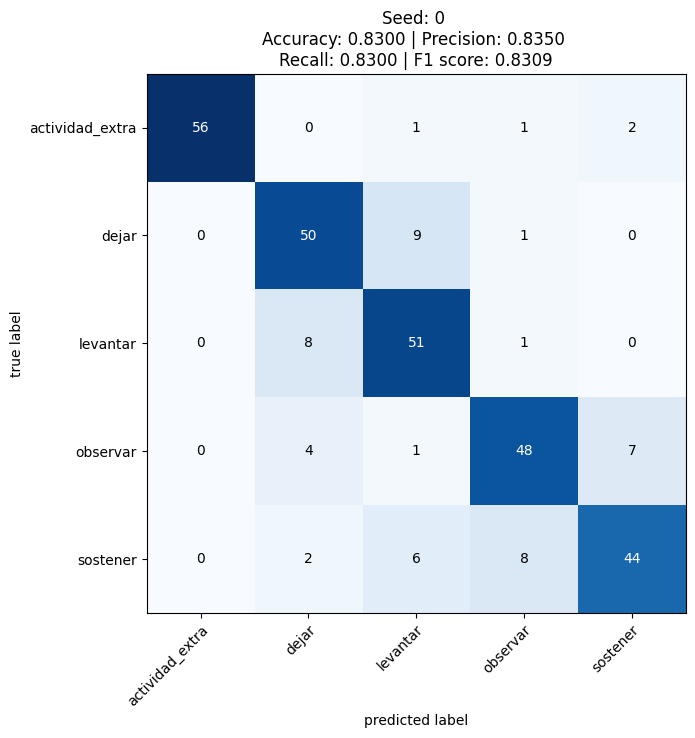

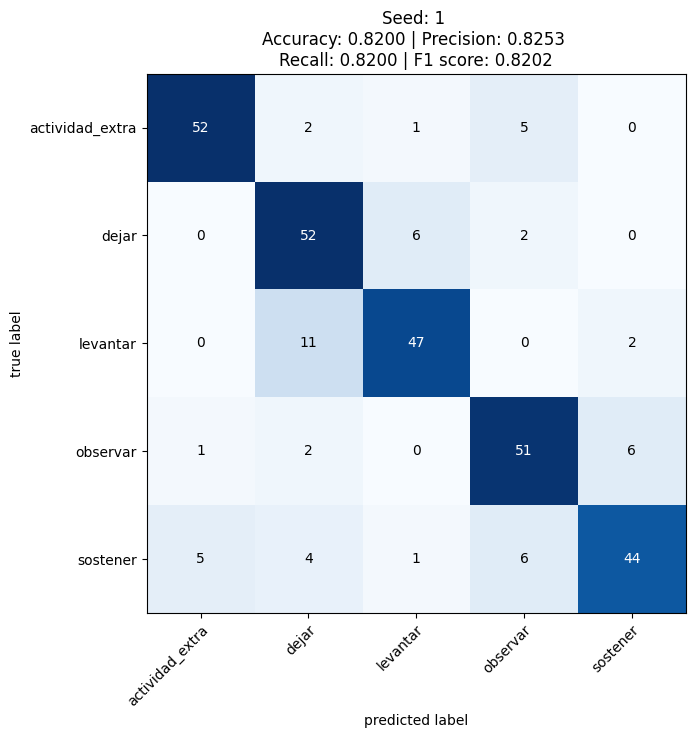

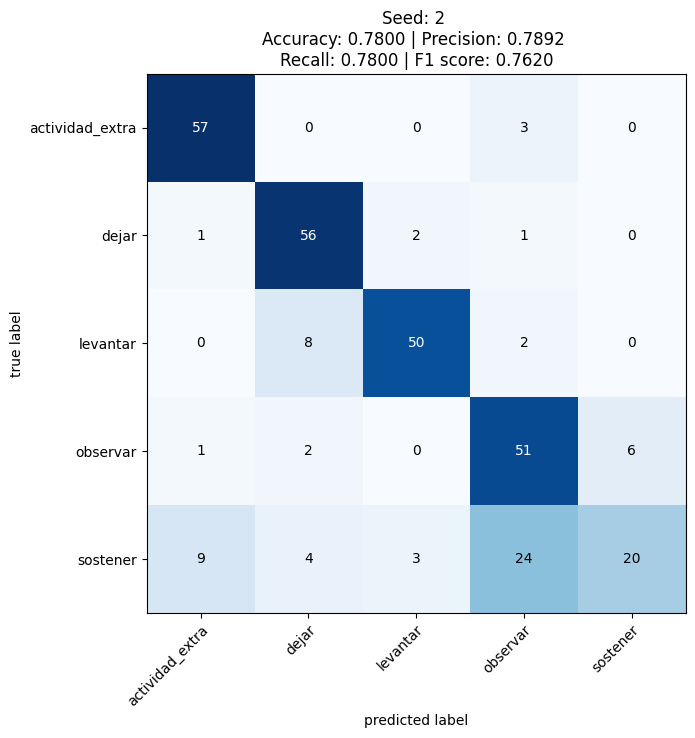

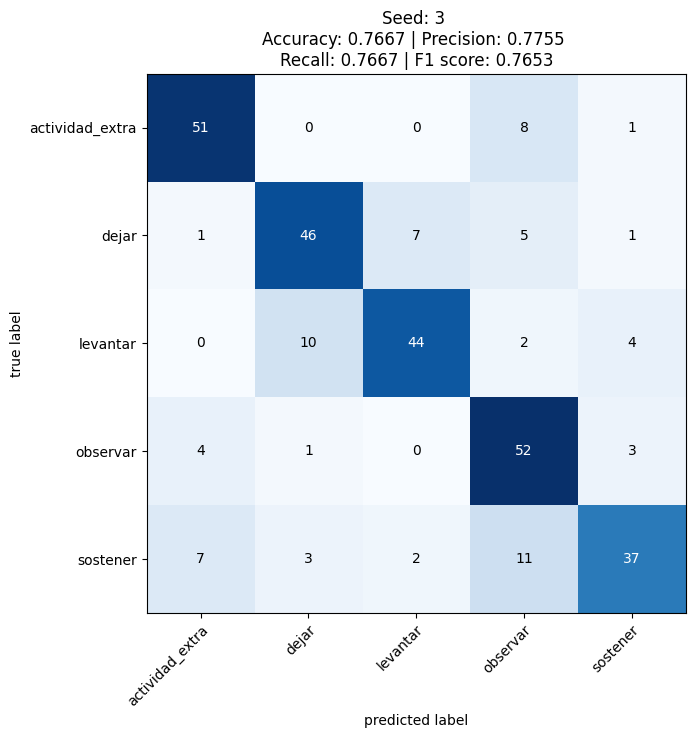

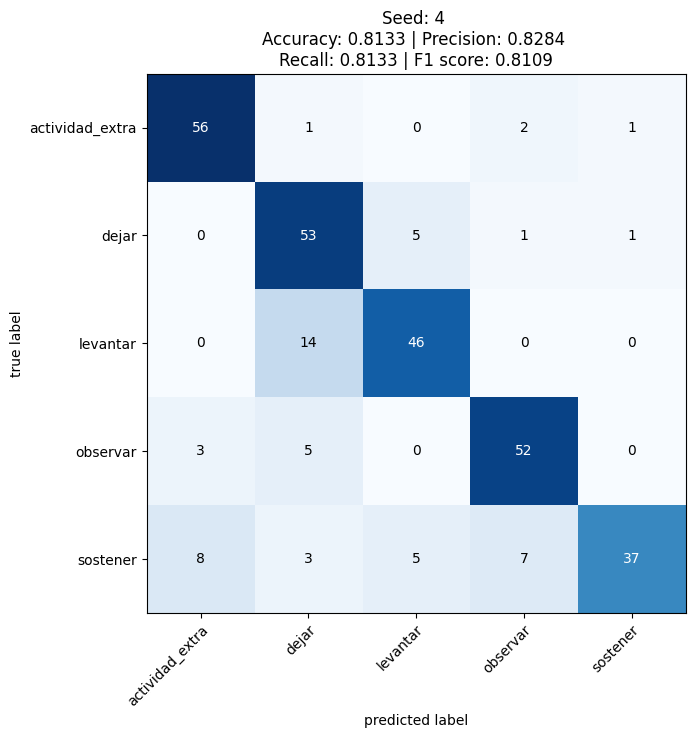

In [28]:
plot_confussion_matrix(experiment_dir)